![](https://static01.nyt.com/athletic/uploads/wp/2022/11/23053501/GettyImages-1443658777-scaled.jpg)

# Introduction

Sports injuries represent a critical concern in university-level athletics, as they can significantly impact both individual performance and team outcomes. The dataset used in this study provides a structured view of injury-related risk factors among football players, categorized into Physical Characteristics (Age, Height, Weight, BMI), Football-Specific Metrics (Playing Position, Training Hours, Matches Played, Injury History), Physical Fitness Assessments (Knee Strength, Hamstring Flexibility, Reaction Time, Balance, Sprint Speed, Agility), Lifestyle Factors (Sleep Hours, Stress Level, Nutrition Quality), and Training Compliance (Warm-Up Routine Adherence). By combining physiological, behavioral, and sports-specific attributes, this dataset allows for a comprehensive exploration of the determinants that contribute to injury occurrence in athletes.

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier 
from xgboost import XGBClassifier

import warnings
from warnings import filterwarnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
filterwarnings("ignore")

# 1.Load Dataset

In [2]:
df=pd.read_csv("/kaggle/input/university-football-injury-prediction-dataset/data.csv")

# 2.Analyzing the Dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         800 non-null    int64  
 1   Height_cm                   800 non-null    int64  
 2   Weight_kg                   800 non-null    int64  
 3   Position                    800 non-null    object 
 4   Training_Hours_Per_Week     800 non-null    float64
 5   Matches_Played_Past_Season  800 non-null    int64  
 6   Previous_Injury_Count       800 non-null    int64  
 7   Knee_Strength_Score         800 non-null    float64
 8   Hamstring_Flexibility       800 non-null    float64
 9   Reaction_Time_ms            800 non-null    float64
 10  Balance_Test_Score          800 non-null    float64
 11  Sprint_Speed_10m_s          800 non-null    float64
 12  Agility_Score               800 non-null    float64
 13  Sleep_Hours_Per_Night       800 non

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,800.0,21.135000,1.991037,18.000000,19.000000,21.000000,23.000000,24.000000
Height_cm,800.0,177.407500,7.148974,154.000000,173.000000,177.000000,182.000000,200.000000
Weight_kg,800.0,73.235000,9.929276,45.000000,66.000000,73.000000,80.000000,105.000000
Training_Hours_Per_Week,800.0,9.951150,2.610395,5.000000,8.127151,9.895710,11.535140,18.866608
Matches_Played_Past_Season,800.0,22.332500,10.311516,5.000000,13.000000,22.000000,32.000000,39.000000
Previous_Injury_Count,800.0,1.536250,1.292584,0.000000,1.000000,1.000000,2.000000,8.000000
Knee_Strength_Score,800.0,74.933249,6.672704,52.391351,70.432656,74.997933,79.632391,93.900051
Hamstring_Flexibility,800.0,79.154123,6.782332,58.180381,74.495959,79.187909,83.813179,100.000000
Reaction_Time_ms,800.0,249.423244,22.532387,180.000000,234.089585,249.127328,265.105082,306.730851
Balance_Test_Score,800.0,83.832337,6.931657,60.059484,79.044910,84.156236,88.877902,100.000000


In [5]:
df.sample(5)

,Age,Height_cm,Weight_kg,Position,Training_Hours_Per_Week,Matches_Played_Past_Season,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,Reaction_Time_ms,Balance_Test_Score,Sprint_Speed_10m_s,Agility_Score,Sleep_Hours_Per_Night,Stress_Level_Score,Nutrition_Quality_Score,Warmup_Routine_Adherence,Injury_Next_Season,BMI
13,19,198,75,Defender,10.026712,28,2,72.172303,75.804658,282.081649,82.108525,5.947923,71.881054,6.452557,46.226068,88.220704,1,1,19.130701
514,21,180,78,Forward,8.991387,7,0,84.900228,84.686499,235.130367,93.728035,5.899484,78.696794,8.986928,51.720122,78.431603,1,0,24.074074
724,18,179,69,Midfielder,8.013180,12,0,72.072755,86.184705,287.652374,78.545712,6.436180,79.650543,7.387684,40.484129,89.484205,0,0,21.534908
479,24,184,64,Midfielder,12.289638,17,2,81.584492,76.104521,297.875719,82.122859,5.990554,82.028531,7.277251,68.040775,64.154037,1,1,18.903592
624,23,171,80,Goalkeeper,5.000000,12,0,78.493240,67.711581,241.753418,81.790430,5.836044,63.818535,7.588724,64.918272,73.342545,0,1,27.358845


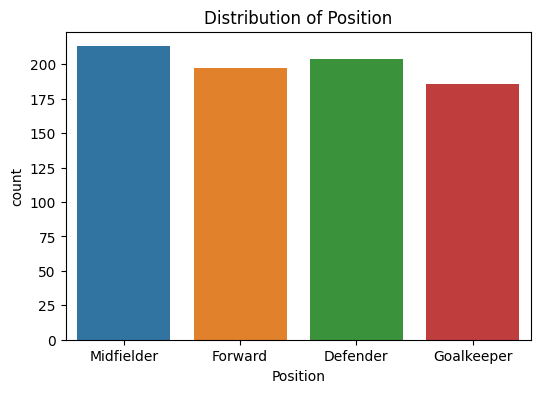

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='Position', data=df)
plt.title('Distribution of Position')
plt.show()

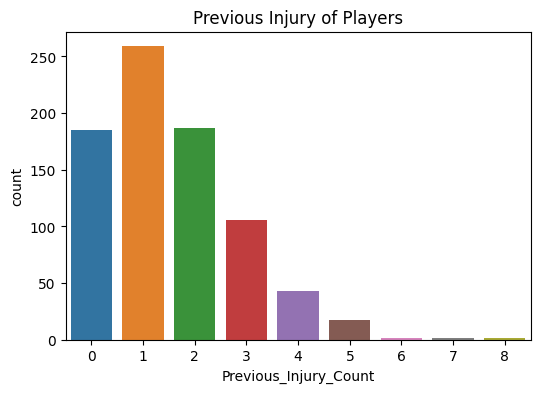

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='Previous_Injury_Count', data=df)
plt.title('Previous Injury of Players')
plt.show()

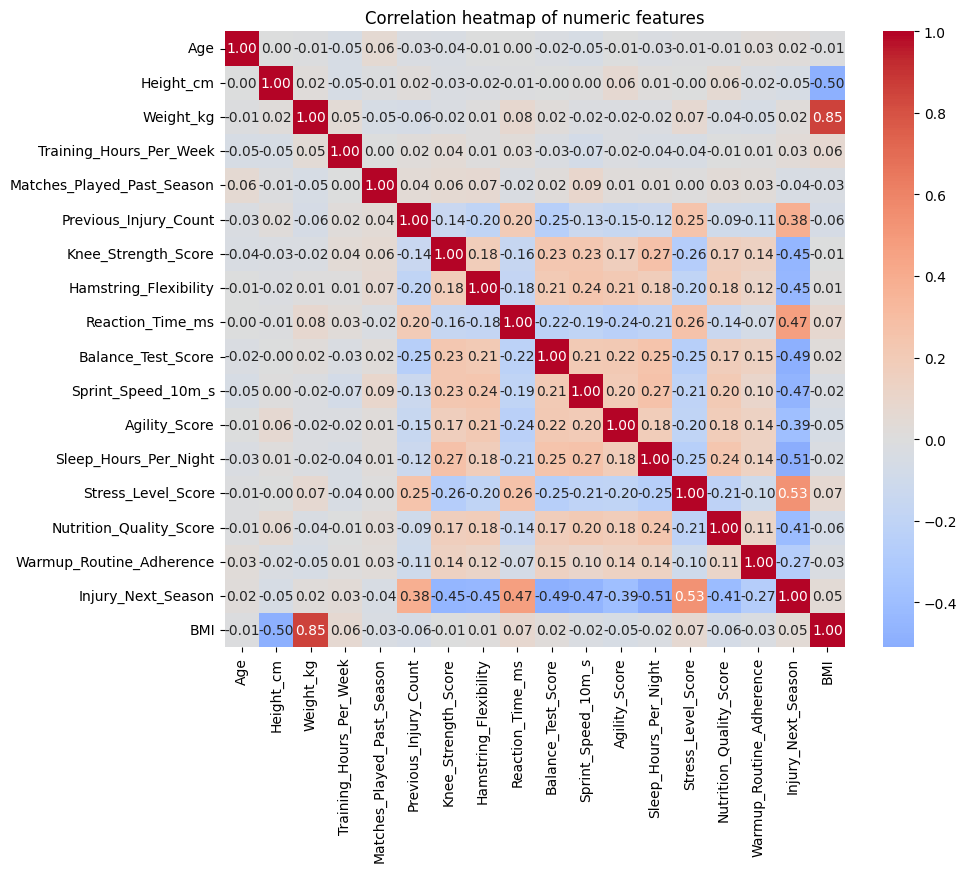

In [8]:
# 4. Correlation heatmap (numeric features only)
numeric = df.select_dtypes(include=np.number)
plt.figure(figsize=(10,8))
sns.heatmap(numeric.corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation heatmap of numeric features')
plt.show()

In this heatmap we can see that Age,Height,Weight,Training Hours and Last Season Matches aren't important for our dataset so we won't use these and we will drop these columns on preprocessing.

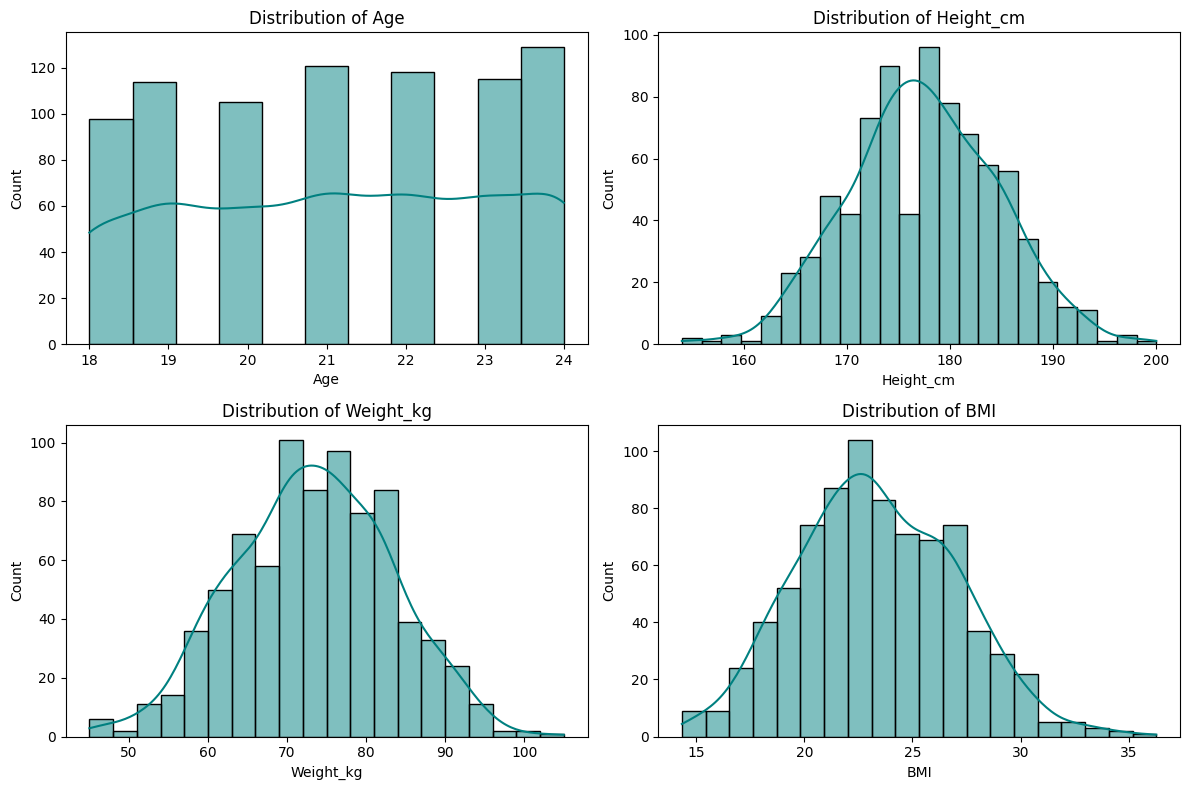

In [9]:
# Histograms for several numeric variables
num_vars = ['Age', 'Height_cm', 'Weight_kg', 'BMI']
plt.figure(figsize=(12, 8))
for i, var in enumerate(num_vars, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[var], kde=True, color='teal')
    plt.title(f'Distribution of {var}')
plt.tight_layout()
plt.show()

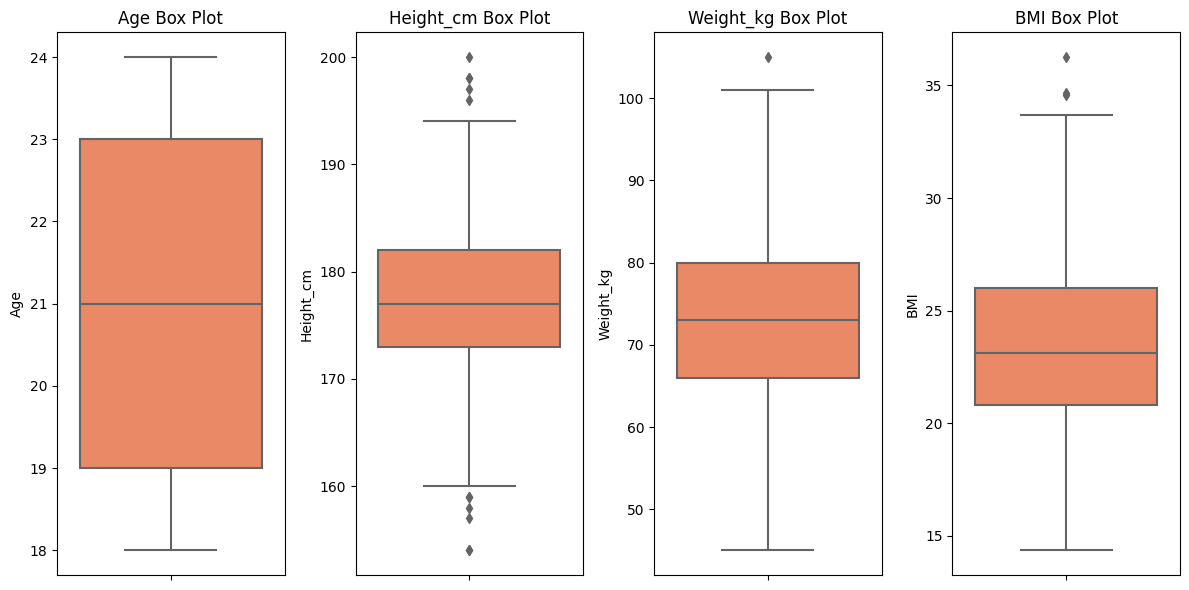

In [10]:
# Box plots to check for outliers in select numeric columns
plt.figure(figsize=(12, 6))
for i, var in enumerate(num_vars, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df[var], color='coral')
    plt.title(f'{var} Box Plot')
plt.tight_layout()
plt.show()

# 3. Preprocessing

In [11]:
df=df.drop(columns=["Age","Matches_Played_Past_Season","Training_Hours_Per_Week","BMI","Height_cm","Weight_kg"])

le = LabelEncoder()
df["Position"] = le.fit_transform(df["Position"])

In [12]:
df.sample(5)

,Position,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,Reaction_Time_ms,Balance_Test_Score,Sprint_Speed_10m_s,Agility_Score,Sleep_Hours_Per_Night,Stress_Level_Score,Nutrition_Quality_Score,Warmup_Routine_Adherence,Injury_Next_Season
718,1,1,73.826454,89.053867,222.077670,86.799796,5.791536,81.983988,8.091259,74.648955,95.487029,1,0
415,1,1,73.901659,86.450279,228.567507,98.332292,6.069767,63.780042,6.948937,49.562687,72.799350,1,0
671,1,0,71.547050,81.804988,271.131253,80.829900,5.449587,75.855223,7.671913,87.065007,77.472988,1,1
215,0,3,75.503843,78.931521,251.252820,69.621798,6.464698,78.686013,5.992217,73.856810,63.020657,0,1
282,2,2,61.371972,79.509753,259.224356,61.365936,6.175275,69.100418,7.194150,65.491734,77.634741,0,1


In [13]:
y = df["Injury_Next_Season"]
x = df.drop(["Injury_Next_Season"], axis=1)

In [14]:
x_train, x_test,y_train,y_test=train_test_split(x,y,random_state=42,train_size=0.85)

# 4. Logistic Regression

In [15]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(x_train, y_train)

# Predict on the test set
y_pred = model.predict(x_test)
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy Score: {acc:.5f}')

Accuracy Score: 0.95000


# 5. RandomForest and XGBModel

In [16]:
rf=RandomForestClassifier(
    n_estimators=300, random_state=42, n_jobs=-1
)
rf_model=rf.fit(x_train,y_train)
rf_model.score(x_test,y_test)

0.9416666666666667

In [17]:
xgb=XGBClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
)
xgb_model=xgb.fit(x_train,y_train)
xgb_model.score(x_test,y_test)

0.9583333333333334

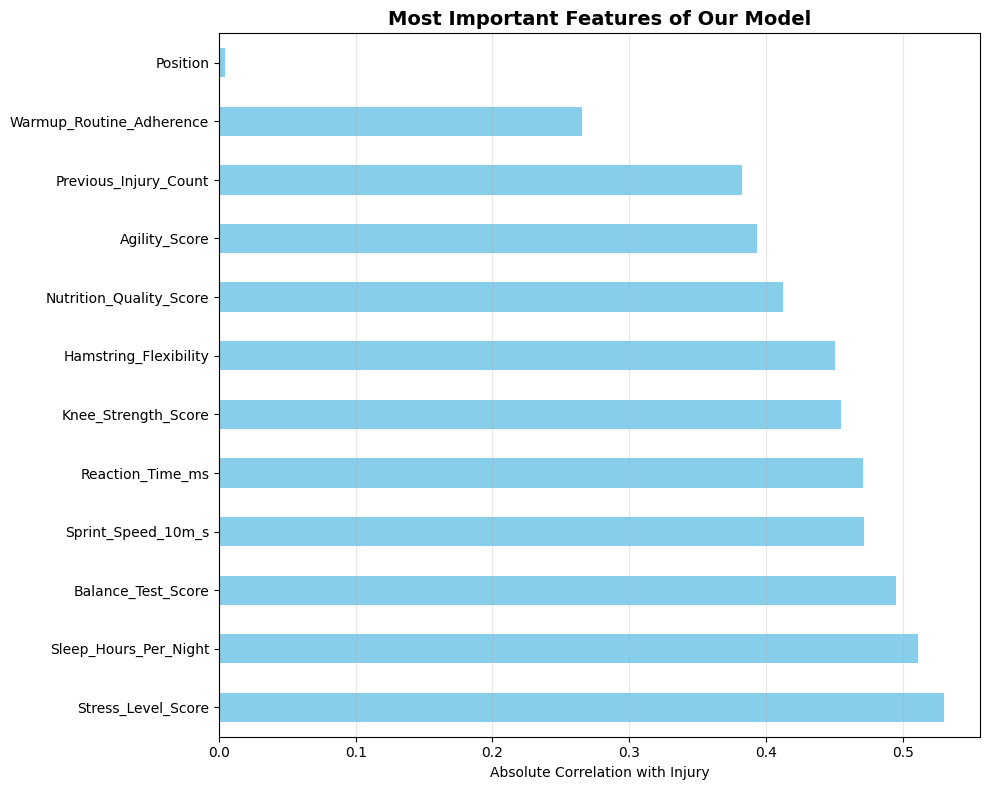

Top correlated features with Injury:
----------------------------------------
Stress_Level_Score  : 0.5300
Sleep_Hours_Per_Night: 0.5109
Balance_Test_Score  : 0.4948
Sprint_Speed_10m_s  : 0.4715
Reaction_Time_ms    : 0.4709
Knee_Strength_Score : 0.4546
Hamstring_Flexibility: 0.4503
Nutrition_Quality_Score: 0.4125
Agility_Score       : 0.3937
Previous_Injury_Count: 0.3822
Warmup_Routine_Adherence: 0.2651
Position            : 0.0044


In [18]:
# Calculate correlations with target (Accident)
correlations = df.select_dtypes(include=[np.number]).corr()["Injury_Next_Season"].abs().sort_values(ascending=False)

# Top 15 correlated features
top_corr_features = correlations.head(15)

# Plot
plt.figure(figsize=(10, 8))
top_corr_features.drop("Injury_Next_Season").plot(kind="barh", color="skyblue")
plt.title("Most Important Features of Our Model", fontsize=14, fontweight="bold")
plt.xlabel("Absolute Correlation with Injury")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Print correlation values
print("Top correlated features with Injury:")
print("-" * 40)
for feature, corr in top_corr_features.items():
    if feature != "Injury_Next_Season":
        print(f"{feature:<20}: {corr:.4f}")

# Conclusion

The analysis of this dataset highlights the multifactorial nature of sports injuries, where both intrinsic (e.g., fitness levels, body composition) and extrinsic factors (e.g., training load, lifestyle habits) interact to determine injury risk. Key predictors identified in the study—such as injury history, hamstring flexibility, training intensity, and sleep quality—align with established findings in sports science, reinforcing the importance of holistic athlete management. These results underscore that injury prevention programs should integrate physical training, recovery strategies, and lifestyle support to minimize risks and optimize player performance.